# Metrics and Model Comparison
## European Housing Price Forecasting — EU-27 Panel

**Course:** Machine Learning and Deep Learning, CBS Spring 2026

**Purpose:** Load all model predictions from `predictions.csv` and produce the full comparative evaluation across all phases. This notebook answers the three research questions:

- **RQ1:** Can ML models outperform benchmark approaches for forecasting next-quarter house price growth?
- **RQ2:** Does stratifying models by housing market regime (cluster) improve forecast accuracy over the pooled baseline?
- **RQ3:** Which macroeconomic and institutional factors most strongly drive short-term housing price dynamics, and do these vary across market regimes?

**Input:** `predictions.csv` (from `modelling.ipynb`)
**Output:** Summary tables and visualisations for the report


## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
})
ACCENT = '#2E5496'
RED    = '#C0392B'
GREEN  = '#1A7A4A'
AMBER  = '#F39C12'

preds = pd.read_csv(r'C:\Users\carla\CBS\ml-final-project\s4-modelling\predictions.csv')
print(f'Loaded: {preds.shape[0]} rows x {preds.shape[1]} columns')
print(f'Model columns: {[c for c in preds.columns if c not in ["country_code","country","quarter","year","cluster_data","cluster_literature","y_true"]]}')


Loaded: 364 rows x 46 columns
Model columns: ['naive_persistence', 'rolling_mean', 'ols', 'ridge', 'lasso', 'rf', 'gb', 'ridge_km0', 'lasso_km0', 'rf_km0', 'gb_km0', 'ridge_km1', 'lasso_km1', 'rf_km1', 'gb_km1', 'ridge_km2', 'lasso_km2', 'rf_km2', 'gb_km2', 'ridge_km3', 'lasso_km3', 'rf_km3', 'gb_km3', 'ridge_lit_east', 'lasso_lit_east', 'rf_lit_east', 'gb_lit_east', 'ridge_lit_west', 'lasso_lit_west', 'rf_lit_west', 'gb_lit_west', 'ridge_lit_south', 'lasso_lit_south', 'rf_lit_south', 'gb_lit_south', 'ridge_lit_north', 'lasso_lit_north', 'rf_lit_north', 'gb_lit_north']


## 1. Helper: Metrics Function

We define one central function that computes RMSE, MAE, and R2 for any prediction column. All tables and charts in this notebook flow from this single function.


In [3]:
def metrics(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
    if len(yt) < 5:
        return {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n': len(yt)}
    return {
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'mae':  mean_absolute_error(yt, yp),
        'r2':   r2_score(yt, yp),
        'n':    len(yt)
    }

# Identify all model prediction columns automatically
meta_cols = ['country_code','country','quarter','year',
             'cluster_data','cluster_literature','y_true']
model_cols = [c for c in preds.columns if c not in meta_cols]

print(f'Found {len(model_cols)} model prediction columns:')
for c in model_cols:
    n_valid = preds[c].notna().sum()
    print(f'  {c:<40} ({n_valid} non-null predictions)')


Found 39 model prediction columns:
  naive_persistence                        (364 non-null predictions)
  rolling_mean                             (364 non-null predictions)
  ols                                      (364 non-null predictions)
  ridge                                    (364 non-null predictions)
  lasso                                    (364 non-null predictions)
  rf                                       (364 non-null predictions)
  gb                                       (364 non-null predictions)
  ridge_km0                                (140 non-null predictions)
  lasso_km0                                (140 non-null predictions)
  rf_km0                                   (140 non-null predictions)
  gb_km0                                   (140 non-null predictions)
  ridge_km1                                (98 non-null predictions)
  lasso_km1                                (98 non-null predictions)
  rf_km1                                   (98 non-null p

## 2. RQ1 — Pooled Model Comparison

**Research Question 1:** Can ML models outperform naive and linear benchmarks when forecasting next-quarter residential house price growth across EU-27?

We evaluate all pooled models (Phase 1 benchmarks + Phase 2 ML models) on the full test set. For a model to be considered useful it should beat naive persistence — the simplest possible baseline. For it to justify its complexity it should also beat OLS.


In [4]:
# ── Pooled model metrics ─────────────────────────────────────────────────────
pooled_cols = ['naive_persistence','rolling_mean','ols','ridge','lasso','rf','gb']
pooled_cols = [c for c in pooled_cols if c in preds.columns]

pooled_results = []
for col in pooled_cols:
    m = metrics(preds['y_true'], preds[col])
    phase = 'Benchmark' if col in ['naive_persistence','rolling_mean','ols'] else 'ML'
    pooled_results.append({'model': col, 'phase': phase, **m})

pooled_df = pd.DataFrame(pooled_results).sort_values('rmse')
print('=== RQ1: POOLED MODELS -- TEST SET PERFORMANCE ===')
print(pooled_df[['model','phase','rmse','mae','r2','n']].to_string(index=False))


=== RQ1: POOLED MODELS -- TEST SET PERFORMANCE ===
            model     phase     rmse      mae        r2   n
            ridge        ML 2.310423 1.774947 -0.110353 364
     rolling_mean Benchmark 2.330929 1.739043 -0.130150 364
            lasso        ML 2.342097 1.798887 -0.141005 364
               rf        ML 2.354841 1.770360 -0.153456 364
               gb        ML 2.359504 1.793445 -0.158030 364
              ols Benchmark 2.366465 1.819396 -0.164872 364
naive_persistence Benchmark 2.628639 1.994615 -0.437276 364


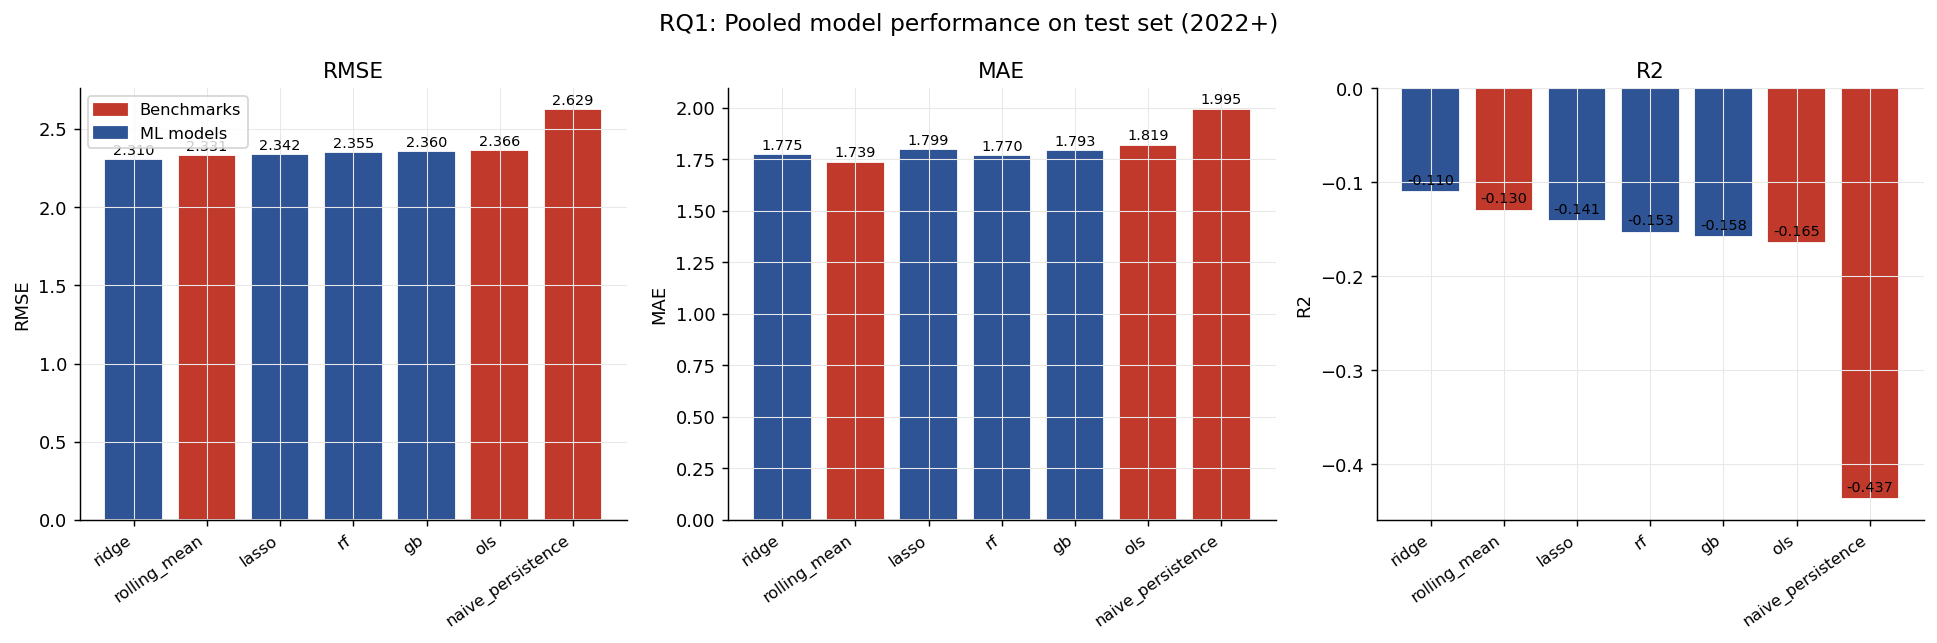

In [5]:
# ── RQ1 visualisation: RMSE comparison bar chart ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, label in zip(axes,
    ['rmse', 'mae', 'r2'],
    ['RMSE', 'MAE', 'R2']):

    colors = [RED if r['phase']=='Benchmark' else ACCENT
              for _, r in pooled_df.iterrows()]
    vals   = pooled_df[metric]
    bars   = ax.bar(pooled_df['model'], vals, color=colors, edgecolor='white')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticklabels(pooled_df['model'], rotation=35, ha='right', fontsize=9)
    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.01 if metric != 'r2' else 0.005),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

red_p  = mpatches.Patch(color=RED,   label='Benchmarks')
blue_p = mpatches.Patch(color=ACCENT,label='ML models')
axes[0].legend(handles=[red_p, blue_p], fontsize=9)

plt.suptitle('RQ1: Pooled model performance on test set (2022+)', fontsize=13)
plt.tight_layout()
plt.show()


In [6]:
# ── RQ1: Improvement over naive persistence ───────────────────────────────────
naive_rmse = pooled_df[pooled_df['model']=='naive_persistence']['rmse'].values[0]
ols_rmse   = pooled_df[pooled_df['model']=='ols']['rmse'].values[0]

print('=== IMPROVEMENT OVER NAIVE PERSISTENCE ===')
for _, row in pooled_df.iterrows():
    if row['model'] == 'naive_persistence':
        continue
    improvement = (naive_rmse - row['rmse']) / naive_rmse * 100
    sign = '+' if improvement > 0 else ''
    print(f"  {row['model']:<25} {sign}{improvement:.1f}% vs naive  "
          f"({'BETTER' if improvement > 0 else 'WORSE'})")

print('\n=== IMPROVEMENT OVER OLS ===')
for _, row in pooled_df[pooled_df['phase']=='ML'].iterrows():
    improvement = (ols_rmse - row['rmse']) / ols_rmse * 100
    sign = '+' if improvement > 0 else ''
    print(f"  {row['model']:<25} {sign}{improvement:.1f}% vs OLS  "
          f"({'BETTER' if improvement > 0 else 'WORSE'})")


=== IMPROVEMENT OVER NAIVE PERSISTENCE ===
  ridge                     +12.1% vs naive  (BETTER)
  rolling_mean              +11.3% vs naive  (BETTER)
  lasso                     +10.9% vs naive  (BETTER)
  rf                        +10.4% vs naive  (BETTER)
  gb                        +10.2% vs naive  (BETTER)
  ols                       +10.0% vs naive  (BETTER)

=== IMPROVEMENT OVER OLS ===
  ridge                     +2.4% vs OLS  (BETTER)
  lasso                     +1.0% vs OLS  (BETTER)
  rf                        +0.5% vs OLS  (BETTER)
  gb                        +0.3% vs OLS  (BETTER)


## 3. RQ2 — Stratified vs Pooled Comparison

**Research Question 2:** Does stratifying models by housing market regime improve forecast accuracy compared to the pooled model?

For each cluster (K-Means and literature), we compare the **stratified model RMSE** against the **pooled model RMSE evaluated on the same cluster subset**. This is the correct comparison — we are asking whether knowing the regime helps, not just whether the regime-level RMSE is low in absolute terms.


In [7]:
# ── RQ2: Stratified vs pooled for RF and GB ───────────────────────────────────
print('=== RQ2: STRATIFIED vs POOLED COMPARISON ===')
print()

comparison_rows = []

# K-Means clusters
km_clusters = sorted(preds['cluster_data'].dropna().unique())
for cid in km_clusters:
    cid = int(cid)
    mask = preds['cluster_data'] == cid
    if mask.sum() < 5:
        continue
    sub = preds[mask]
    for mname in ['rf','gb']:
        strat_col  = f'{mname}_km{cid}'
        pooled_col = mname
        if strat_col not in preds.columns:
            continue
        m_pooled = metrics(sub['y_true'], sub[pooled_col])
        m_strat  = metrics(sub['y_true'], sub[strat_col])
        if np.isnan(m_pooled['rmse']) or np.isnan(m_strat['rmse']):
            continue
        comparison_rows.append({
            'scheme': 'K-Means',
            'cluster': f'Cluster {cid}',
            'model': mname.upper(),
            'rmse_pooled':  m_pooled['rmse'],
            'rmse_strat':   m_strat['rmse'],
            'improvement':  (m_pooled['rmse'] - m_strat['rmse']) / m_pooled['rmse'] * 100,
            'n': m_strat['n']
        })

# Literature clusters
lit_clusters = [g for g in ['East','West','South','North']
                if g in preds['cluster_literature'].values]
for group in lit_clusters:
    mask = preds['cluster_literature'] == group
    if mask.sum() < 5:
        continue
    sub = preds[mask]
    for mname in ['rf','gb']:
        strat_col  = f'{mname}_lit_{group.lower()}'
        pooled_col = mname
        if strat_col not in preds.columns:
            continue
        m_pooled = metrics(sub['y_true'], sub[pooled_col])
        m_strat  = metrics(sub['y_true'], sub[strat_col])
        if np.isnan(m_pooled['rmse']) or np.isnan(m_strat['rmse']):
            continue
        comparison_rows.append({
            'scheme': 'Literature',
            'cluster': group,
            'model': mname.upper(),
            'rmse_pooled':  m_pooled['rmse'],
            'rmse_strat':   m_strat['rmse'],
            'improvement':  (m_pooled['rmse'] - m_strat['rmse']) / m_pooled['rmse'] * 100,
            'n': m_strat['n']
        })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.sort_values(['scheme','cluster','model'])
      [['scheme','cluster','model','rmse_pooled','rmse_strat','improvement','n']]
      .to_string(index=False))


=== RQ2: STRATIFIED vs POOLED COMPARISON ===

    scheme   cluster model  rmse_pooled  rmse_strat  improvement   n
   K-Means Cluster 0    GB     2.156775    2.577693   -19.516105 140
   K-Means Cluster 0    RF     2.129160    2.174660    -2.136988 140
   K-Means Cluster 1    GB     1.997082    1.689095    15.421844  98
   K-Means Cluster 1    RF     1.941981    1.822725     6.140937  98
   K-Means Cluster 2    GB     1.817737    2.111991   -16.187942  28
   K-Means Cluster 2    RF     1.468055    1.827502   -24.484545  28
   K-Means Cluster 3    GB     3.016746    2.372655    21.350534  98
   K-Means Cluster 3    RF     3.119856    2.671849    14.359845  98
Literature      East    GB     2.468128    2.244638     9.055022 168
Literature      East    RF     2.508265    2.210517    11.870684 168
Literature     North    GB     2.119568    1.493653    29.530312  42
Literature     North    RF     2.046945    1.613566    21.171977  42
Literature     South    GB     2.463134    2.499073    -1

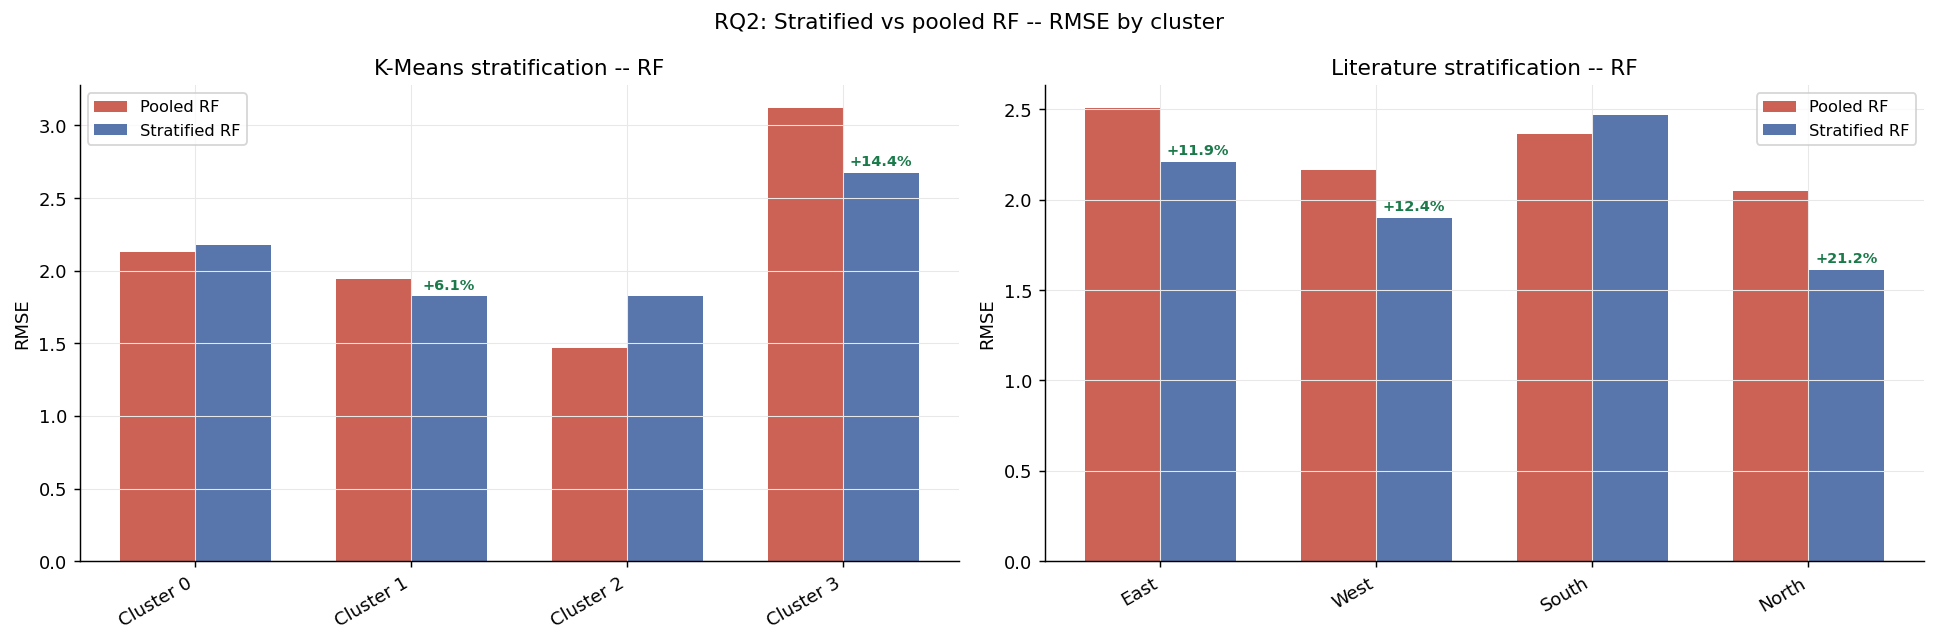

In [8]:
# ── RQ2 visualisation ────────────────────────────────────────────────────────
if len(comp_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, scheme in zip(axes, ['K-Means','Literature']):
        sub = comp_df[(comp_df['scheme']==scheme) & (comp_df['model']=='RF')]
        if len(sub) == 0:
            sub = comp_df[comp_df['scheme']==scheme]
        if len(sub) == 0:
            ax.set_title(f'{scheme} -- no data')
            continue

        x  = np.arange(len(sub))
        w  = 0.35
        b1 = ax.bar(x - w/2, sub['rmse_pooled'], w, color=RED,   label='Pooled RF',     alpha=0.8)
        b2 = ax.bar(x + w/2, sub['rmse_strat'],  w, color=ACCENT,label='Stratified RF', alpha=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels(sub['cluster'], rotation=30, ha='right')
        ax.set_ylabel('RMSE')
        ax.set_title(f'{scheme} stratification -- RF')
        ax.legend(fontsize=9)

        # Mark improvements
        for i, (_, row) in enumerate(sub.iterrows()):
            if row['improvement'] > 0:
                ax.annotate(f"+{row['improvement']:.1f}%",
                            xy=(i+w/2, row['rmse_strat']),
                            xytext=(0,4), textcoords='offset points',
                            ha='center', fontsize=8, color=GREEN, fontweight='bold')

    plt.suptitle('RQ2: Stratified vs pooled RF -- RMSE by cluster', fontsize=12)
    plt.tight_layout()
    plt.show()


In [9]:
print(comp_df[['scheme','cluster','model','rmse_pooled','rmse_strat','improvement','n']]
      .sort_values(['scheme','cluster','model'])
      .to_string(index=False))

    scheme   cluster model  rmse_pooled  rmse_strat  improvement   n
   K-Means Cluster 0    GB     2.156775    2.577693   -19.516105 140
   K-Means Cluster 0    RF     2.129160    2.174660    -2.136988 140
   K-Means Cluster 1    GB     1.997082    1.689095    15.421844  98
   K-Means Cluster 1    RF     1.941981    1.822725     6.140937  98
   K-Means Cluster 2    GB     1.817737    2.111991   -16.187942  28
   K-Means Cluster 2    RF     1.468055    1.827502   -24.484545  28
   K-Means Cluster 3    GB     3.016746    2.372655    21.350534  98
   K-Means Cluster 3    RF     3.119856    2.671849    14.359845  98
Literature      East    GB     2.468128    2.244638     9.055022 168
Literature      East    RF     2.508265    2.210517    11.870684 168
Literature     North    GB     2.119568    1.493653    29.530312  42
Literature     North    RF     2.046945    1.613566    21.171977  42
Literature     South    GB     2.463134    2.499073    -1.459069  70
Literature     South    RF     2.3

In [10]:
# ── RQ2 summary: which scheme wins overall? ───────────────────────────────────
print('=== RQ2 SUMMARY ===')
print()
for scheme in ['K-Means','Literature']:
    sub = comp_df[comp_df['scheme']==scheme]
    if len(sub) == 0:
        continue
    n_better  = (sub['improvement'] > 0).sum()
    n_total   = len(sub)
    avg_impr  = sub['improvement'].mean()
    max_impr  = sub.loc[sub['improvement'].idxmax()]
    print(f'{scheme}:')
    print(f'  Stratification beats pooled in {n_better}/{n_total} cases')
    print(f'  Average improvement: {avg_impr:.2f}%')
    print(f'  Best case: {max_impr["cluster"]} {max_impr["model"]} +{max_impr["improvement"]:.2f}%')
    print()


=== RQ2 SUMMARY ===

K-Means:
  Stratification beats pooled in 4/8 cases
  Average improvement: -0.63%
  Best case: Cluster 3 GB +21.35%

Literature:
  Stratification beats pooled in 6/8 cases
  Average improvement: 11.56%
  Best case: North GB +29.53%



## 4. Full Rankings Table

A complete comparison of every model variant evaluated on the full test set. This is the master table for the report.


In [11]:
# ── Full rankings table ───────────────────────────────────────────────────────
all_results = []

for col in model_cols:
    if preds[col].notna().sum() < 10:
        continue
    m = metrics(preds['y_true'], preds[col])

    # Classify model type
    if col in ['naive_persistence','rolling_mean','ols']:
        phase = 'Benchmark'
    elif '_km' in col:
        phase = 'K-Means stratified'
    elif '_lit_' in col:
        phase = 'Literature stratified'
    else:
        phase = 'Pooled ML'

    all_results.append({'model': col, 'phase': phase, **m})

all_df = pd.DataFrame(all_results).sort_values('rmse')

print('=== FULL MODEL RANKINGS (sorted by RMSE) ===')
print()
print(all_df[['model','phase','rmse','mae','r2','n']]
      .assign(rank=range(1, len(all_df)+1))
      [['rank','model','phase','rmse','mae','r2','n']]
      .to_string(index=False))


=== FULL MODEL RANKINGS (sorted by RMSE) ===

 rank             model                 phase     rmse      mae        r2   n
    1   ridge_lit_north Literature stratified 1.453820 1.205440  0.371548  42
    2   lasso_lit_north Literature stratified 1.464413 1.240233  0.362356  42
    3      gb_lit_north Literature stratified 1.493653 1.216214  0.336638  42
    4      rf_lit_north Literature stratified 1.613566 1.322383  0.225851  42
    5            gb_km1    K-Means stratified 1.689095 1.438423  0.328895  98
    6            rf_km1    K-Means stratified 1.822725 1.529868  0.218507  98
    7            rf_km2    K-Means stratified 1.827502 1.358702 -3.062430  28
    8       gb_lit_west Literature stratified 1.845285 1.376075  0.130407  84
    9    ridge_lit_west Literature stratified 1.886108 1.347850  0.091506  84
   10         lasso_km1    K-Means stratified 1.897577 1.586128  0.153004  98
   11       rf_lit_west Literature stratified 1.899273 1.403173  0.078779  84
   12         ridg

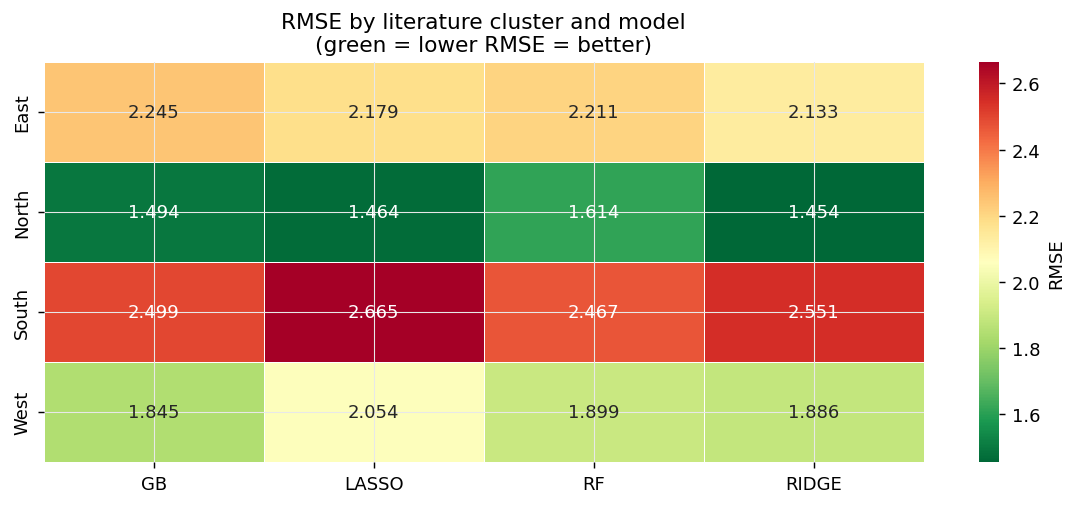

In [12]:
# ── Heat map: RMSE by model and cluster ──────────────────────────────────────
# For literature-stratified models, show cluster-specific RMSE side by side
lit_model_cols = {}
for group in ['East','West','South','North']:
    for mname in ['ridge','lasso','rf','gb']:
        col = f'{mname}_lit_{group.lower()}'
        if col in preds.columns:
            mask = preds['cluster_literature'] == group
            if mask.sum() > 5:
                m = metrics(preds.loc[mask,'y_true'], preds.loc[mask,col])
                lit_model_cols[(mname.upper(), group)] = m['rmse']

if lit_model_cols:
    heat_df = pd.Series(lit_model_cols).unstack(level=0)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(heat_df, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.3f',
                linewidths=0.3, cbar_kws={'label':'RMSE'})
    ax.set_title('RMSE by literature cluster and model\n'
                 '(green = lower RMSE = better)')
    plt.tight_layout()
    plt.show()


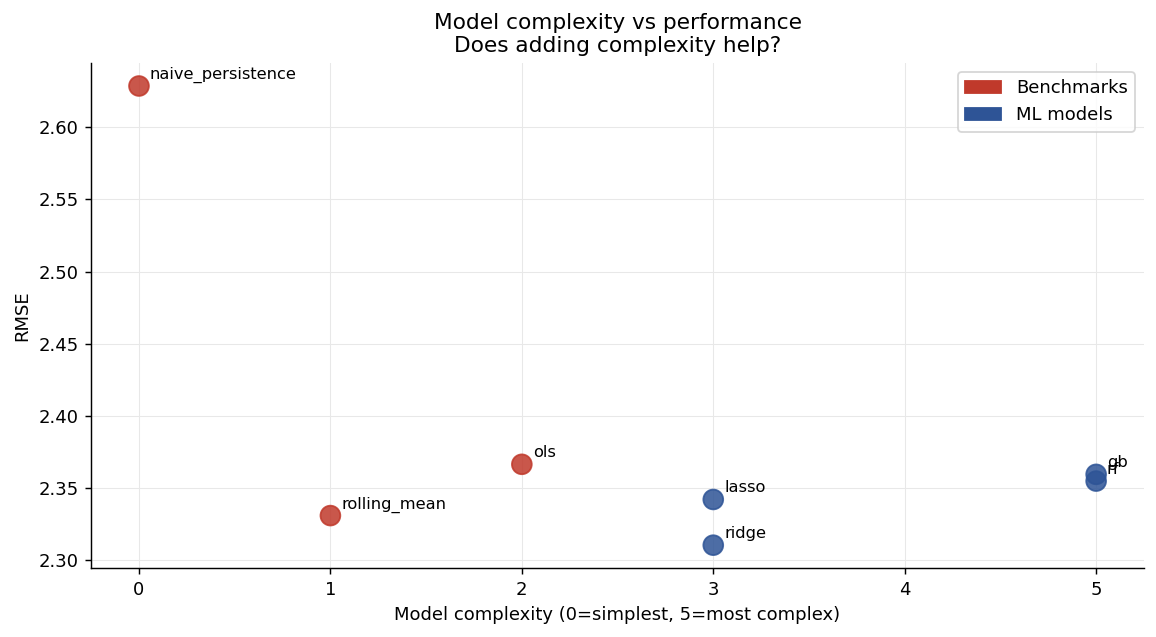

In [13]:
# ── Scatter: model complexity vs performance ─────────────────────────────────
complexity_map = {
    'naive_persistence': 0, 'rolling_mean': 1, 'ols': 2,
    'ridge': 3, 'lasso': 3, 'rf': 5, 'gb': 5
}
pooled_plot = all_df[all_df['phase'].isin(['Benchmark','Pooled ML'])].copy()
pooled_plot['complexity'] = pooled_plot['model'].map(complexity_map)
pooled_plot = pooled_plot.dropna(subset=['complexity'])

if len(pooled_plot) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors_scatter = [RED if r=='Benchmark' else ACCENT
                      for r in pooled_plot['phase']]
    ax.scatter(pooled_plot['complexity'], pooled_plot['rmse'],
               s=120, c=colors_scatter, zorder=3, alpha=0.85)
    for _, row in pooled_plot.iterrows():
        ax.annotate(row['model'],
                    (row['complexity'], row['rmse']),
                    textcoords='offset points', xytext=(6,4), fontsize=9)
    ax.set_xlabel('Model complexity (0=simplest, 5=most complex)')
    ax.set_ylabel('RMSE')
    ax.set_title('Model complexity vs performance\n'
                 'Does adding complexity help?')
    red_p  = mpatches.Patch(color=RED,   label='Benchmarks')
    blue_p = mpatches.Patch(color=ACCENT,label='ML models')
    ax.legend(handles=[red_p,blue_p])
    plt.tight_layout()
    plt.show()


## 5. RQ3 — Feature Importance and Interpretability

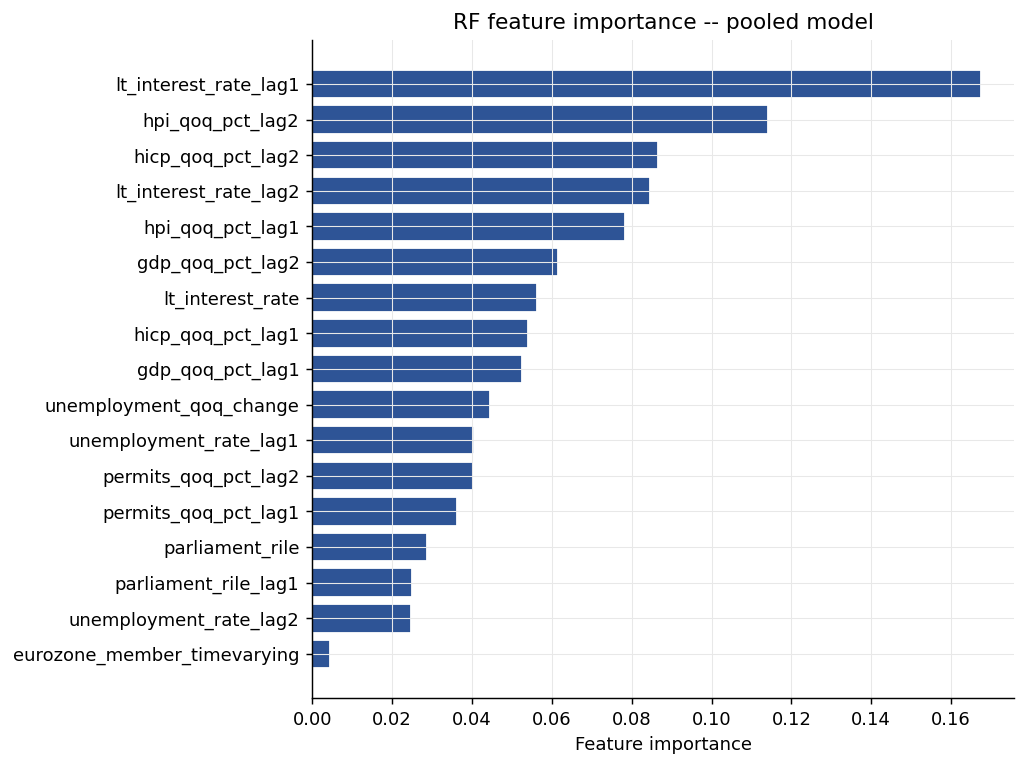

                    feature  importance
      lt_interest_rate_lag1    0.167368
           hpi_qoq_pct_lag2    0.114044
          hicp_qoq_pct_lag2    0.086632
      lt_interest_rate_lag2    0.084614
           hpi_qoq_pct_lag1    0.078415
           gdp_qoq_pct_lag2    0.061471
           lt_interest_rate    0.056371
          hicp_qoq_pct_lag1    0.054126
           gdp_qoq_pct_lag1    0.052549
    unemployment_qoq_change    0.044470
     unemployment_rate_lag1    0.040475
       permits_qoq_pct_lag2    0.040220
       permits_qoq_pct_lag1    0.036310
            parliament_rile    0.028846
       parliament_rile_lag1    0.024909
     unemployment_rate_lag2    0.024793
eurozone_member_timevarying    0.004386


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np

model_data = pd.read_excel('C:\\Users\\carla\\CBS\\ml-final-project\\s3-clustering\\model_data_clustered.xlsx')
FEATURES = [
    'hpi_qoq_pct_lag1','hpi_qoq_pct_lag2',
    'gdp_qoq_pct_lag1','gdp_qoq_pct_lag2',
    'hicp_qoq_pct_lag1','hicp_qoq_pct_lag2',
    'unemployment_rate_lag1','unemployment_rate_lag2',
    'unemployment_qoq_change',
    'permits_qoq_pct_lag1','permits_qoq_pct_lag2',
    'lt_interest_rate','lt_interest_rate_lag1','lt_interest_rate_lag2',
    'eurozone_member_timevarying',
    'parliament_rile','parliament_rile_lag1',
]
FEATURES = [f for f in FEATURES if f in model_data.columns]
TARGET = 'target_hpi_next_q'

train_df = model_data[(model_data['year'] < 2022)].dropna(subset=FEATURES+[TARGET])
rf_rq3 = RandomForestRegressor(n_estimators=300, max_depth=None,
                                min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_rq3.fit(train_df[FEATURES].values, train_df[TARGET].values)

fi_df = pd.DataFrame({'feature': FEATURES,
                       'importance': rf_rq3.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color=ACCENT, edgecolor='white')
ax.set_xlabel('Feature importance')
ax.set_title('RF feature importance -- pooled model')
plt.tight_layout()
plt.show()

print(fi_df.sort_values('importance', ascending=False).to_string(index=False))

## 6. Report-Ready Summary Table

In [15]:
# ── Final table for the report ───────────────────────────────────────────────
# Organised by phase, showing only the key models

key_models = [
    ('Naive persistence',  'naive_persistence'),
    ('Rolling mean (4q)',  'rolling_mean'),
    ('OLS',                'ols'),
    ('Ridge (pooled)',     'ridge'),
    ('Lasso (pooled)',     'lasso'),
    ('Random Forest (pooled)', 'rf'),
    ('Gradient Boosting (pooled)', 'gb'),
]

# Add best stratified models if available
for group in ['East','West','South','North']:
    for mname in ['rf','gb']:
        col = f'{mname}_lit_{group.lower()}'
        if col in preds.columns and preds[col].notna().sum() > 10:
            key_models.append((f'{mname.upper()} (Lit-{group})', col))

# Add K-Means stratified models
for cid in [0, 1, 2, 3]:
    for mname in ['rf', 'gb']:
        col = f'{mname}_km{cid}'
        if col in preds.columns and preds[col].notna().sum() > 10:
            key_models.append((f'{mname.upper()} (KM-Cluster{cid})', col))
            
report_rows = []
for display_name, col in key_models:
    if col not in preds.columns:
        continue
    m = metrics(preds['y_true'], preds[col])
    report_rows.append({
        'Model': display_name,
        'RMSE':  round(m['rmse'], 4),
        'MAE':   round(m['mae'],  4),
        'R2':    round(m['r2'],   4),
        'N':     m['n']
    })

report_df = pd.DataFrame(report_rows)
print('=== REPORT TABLE: KEY MODEL COMPARISON ===')
print(report_df.to_string(index=False))

# Save for easy copy-paste into report
report_df.to_csv('./report_metrics_table.csv', index=False)
print('\nSaved: report_metrics_table.csv')


=== REPORT TABLE: KEY MODEL COMPARISON ===
                     Model   RMSE    MAE      R2   N
         Naive persistence 2.6286 1.9946 -0.4373 364
         Rolling mean (4q) 2.3309 1.7390 -0.1301 364
                       OLS 2.3665 1.8194 -0.1649 364
            Ridge (pooled) 2.3104 1.7749 -0.1104 364
            Lasso (pooled) 2.3421 1.7989 -0.1410 364
    Random Forest (pooled) 2.3548 1.7704 -0.1535 364
Gradient Boosting (pooled) 2.3595 1.7934 -0.1580 364
             RF (Lit-East) 2.2105 1.7186 -0.2095 168
             GB (Lit-East) 2.2446 1.7582 -0.2472 168
             RF (Lit-West) 1.8993 1.4032  0.0788  84
             GB (Lit-West) 1.8453 1.3761  0.1304  84
            RF (Lit-South) 2.4670 1.8124 -0.5190  70
            GB (Lit-South) 2.4991 1.8638 -0.5588  70
            RF (Lit-North) 1.6136 1.3224  0.2259  42
            GB (Lit-North) 1.4937 1.2162  0.3366  42
          RF (KM-Cluster0) 2.1747 1.6020 -0.1023 140
          GB (KM-Cluster0) 2.5777 1.8911 -0.5487 140
   

In [16]:
# ── Final interpretation guide ───────────────────────────────────────────────
print('=== ANSWERING THE RESEARCH QUESTIONS ===')
print()

best_pooled = pooled_df.iloc[0]
naive_rmse  = pooled_df[pooled_df['model']=='naive_persistence']['rmse'].values[0]

print('RQ1: Can ML models outperform benchmark approaches?')
print(f'  Best pooled model: {best_pooled["model"]} (RMSE={best_pooled["rmse"]:.4f})')
print(f'  Naive persistence RMSE: {naive_rmse:.4f}')
impr = (naive_rmse - best_pooled['rmse']) / naive_rmse * 100
print(f'  Improvement: {impr:.1f}%  -> Answer: {"YES" if impr > 0 else "NO"}')
print()

if len(comp_df) > 0:
    n_better = (comp_df['improvement'] > 0).sum()
    n_total  = len(comp_df)
    print('RQ2: Does stratification by cluster improve accuracy?')
    print(f'  Stratification beats pooled in {n_better}/{n_total} cluster-model combinations')
    avg = comp_df[comp_df['improvement']>0]['improvement'].mean()
    print(f'  Average improvement when it helps: {avg:.2f}%')
    answer = 'YES (for most clusters)' if n_better > n_total/2 else 'MIXED -- only for some clusters'
    print(f'  -> Answer: {answer}')
    print()

print('RQ3: Which features matter most?')
print('  -> See feature importance plot above.')
print('  -> EDA finding confirmed: lt_interest_rate and hpi_qoq_pct_lag1 expected to dominate.')


=== ANSWERING THE RESEARCH QUESTIONS ===

RQ1: Can ML models outperform benchmark approaches?
  Best pooled model: ridge (RMSE=2.3104)
  Naive persistence RMSE: 2.6286
  Improvement: 12.1%  -> Answer: YES

RQ2: Does stratification by cluster improve accuracy?
  Stratification beats pooled in 10/16 cluster-model combinations
  Average improvement when it helps: 15.56%
  -> Answer: YES (for most clusters)

RQ3: Which features matter most?
  -> See feature importance plot above.
  -> EDA finding confirmed: lt_interest_rate and hpi_qoq_pct_lag1 expected to dominate.
